# Fluorescence lifetimes of 4 fluorophores at 3 nm distance

In [13]:
import numpy as np

import fluopy.analysis as an
import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = (
    r"D:\python_output\Chapter_I\1_13_multi_f_et_adjustments\fluorescence_lifetimes"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Note** The fluorescence lifetimes will be simulated using a continuous excitation regime to accerate the simulation. The analyzed S1 durations will hence represent the time difference of between excitation and emission and not the time difference of previous laser pulse and emission. Also, only S1 durations that end up in fluorescence will be analyzed.

## $<\kappa^2>$ of $\frac{2}{3}$ 

In [14]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna",
    count=3,
    distance=3,
    shape="square",
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

In [29]:
sim = si.Simulation(transition_set)
sim.run(
    size=1e8, use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_5"
)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


In [30]:
analysis = an.Analysis(sim)
fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")

In [31]:
fluorescence_lifetimes.mean()

np.float64(1.6409764013126586e-09)

In [38]:
indices = transition_set.combined_state_transitions_df.index[
    transition_set.combined_state_transitions_df["abbreviation"] == "OET_1"
]

In [6]:
1 - 0.042 / (1 + 0.042)

0.9596928982725528

In [ ]:
occurrences = np.isin(sim.transition_series, indices).sum()
occurrences

np.int64(2075931)

: 

In [34]:
sim.state_series

array([0, 1, 3, 6, 7, 9], dtype=int8)

## $<\kappa^2>$ distribution

In [23]:
sim_distr = si.Simulation(transition_set)
sim_distr.run(
    size=1e3,
    kap_sq_var=True,
    minimum_rate=1e9,
    use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


In [16]:
sim_distr.time_series[-1]

np.float64(26.97237531534093)

In [17]:
analysis_distr = an.Analysis(sim_distr)

In [22]:
analysis_distr.frequency_transitions

array([4.99602026e-01, 1.12469833e-01, 5.87615000e-04, 2.83004700e-03,
       5.73000000e-07, 2.20900000e-06, 5.73900000e-06, 5.73900000e-06,
       3.02864512e-01, 5.81303000e-04, 2.02595000e-04, 0.00000000e+00,
       3.13420410e-02, 1.30395700e-03, 6.97675600e-03, 2.45100000e-06,
       5.94804200e-03, 1.45159620e-02, 7.89661700e-03, 1.32349500e-03,
       3.31911100e-03, 3.31000000e-07, 2.59951800e-03, 5.61952800e-03])

array([[<Axes: ylabel='Prob. occurrence'>]], dtype=object)

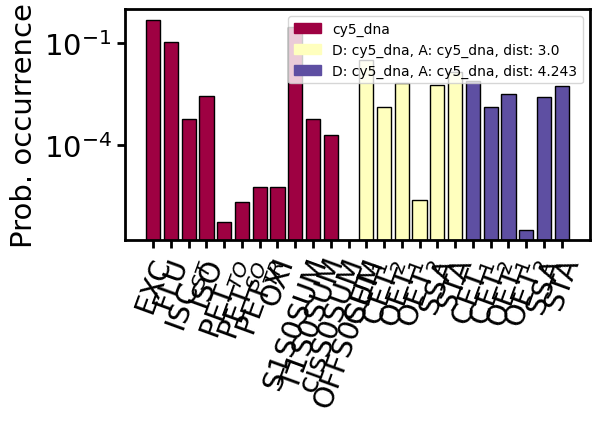

In [21]:
analysis_distr.plot_frequency_transitions()

In [18]:
fluorescence_lifetimes_distr = analysis_distr.get_emitting_transition_lifetimes(
    "cy5_dna"
)

In [26]:
analysis_distr = an.Analysis(sim_distr)
fluorescence_lifetimes_distr = analysis_distr.get_emitting_transition_lifetimes(
    "cy5_dna"
)

In [34]:
fluorescence_lifetimes_distr.mean()

np.float64(1.646029121976527e-09)